### **Multiple Linear Regression**
* Multiple Linear Regression is used when we have more than One Indepandant Variables and One Depandnat Variable.

In [2]:
import pandas as pd

In [10]:
df = pd.read_csv('economic_index.csv')

In [11]:
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


* Droping Unnecessary Columns

In [12]:
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [13]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [ ]:
## check Null Values 

df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [18]:
### lets do some visualization
import seaborn as sns
import matplotlib.pyplot as plt

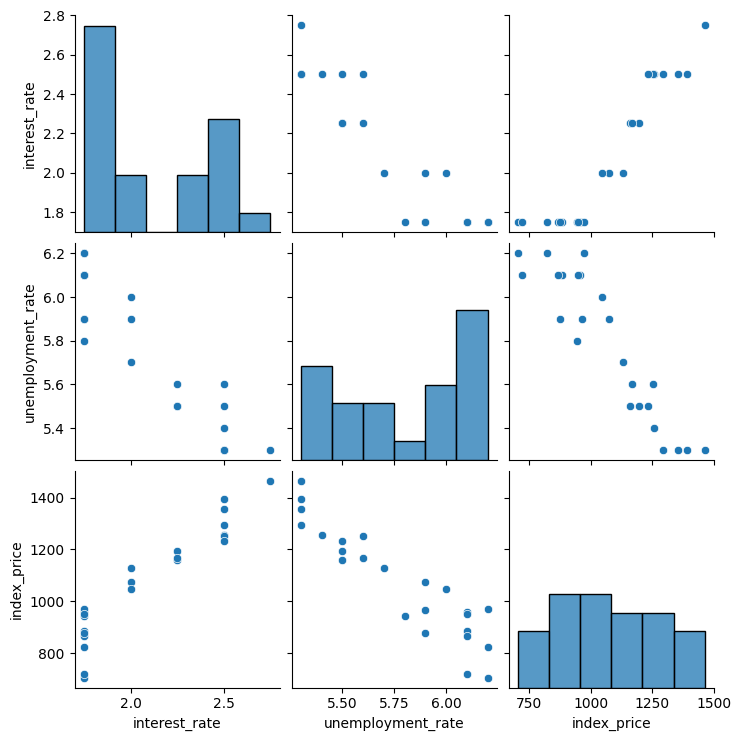

In [19]:
sns.pairplot(df)
plt.show()

`Conclusion`
* Their is a positive relationship b/w index price and interest rate
* Their is a negative relationship b/w index price and unimployment rate

In [20]:
## lets find corrlation 
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: >

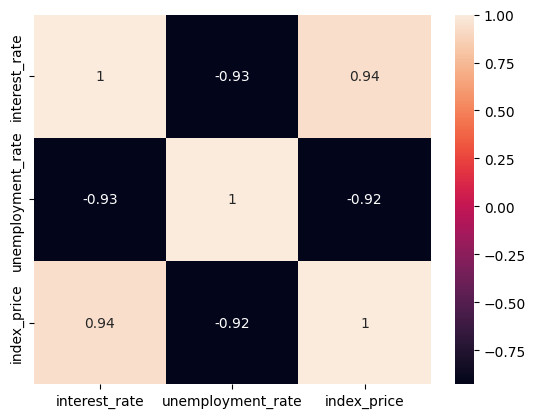

In [21]:
sns.heatmap(df.corr(),annot=True)

* Positive correlation b/w index price and interest rate
* Negative correlation b/w index price and unimplyment rate

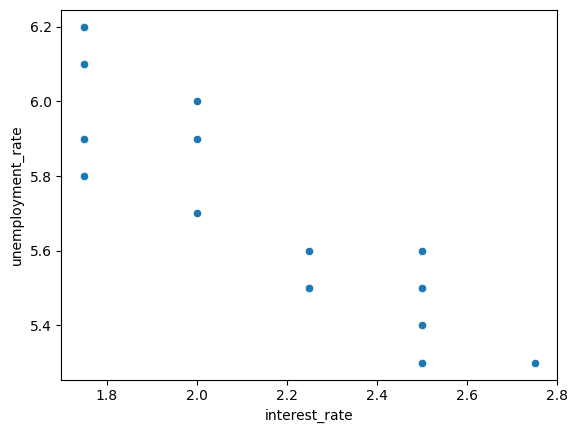

In [29]:
## Visualization of Indepandant variable 
sns.scatterplot(x='interest_rate',y ='unemployment_rate',data=df)
plt.show()

<Axes: xlabel='index_price', ylabel='interest_rate'>

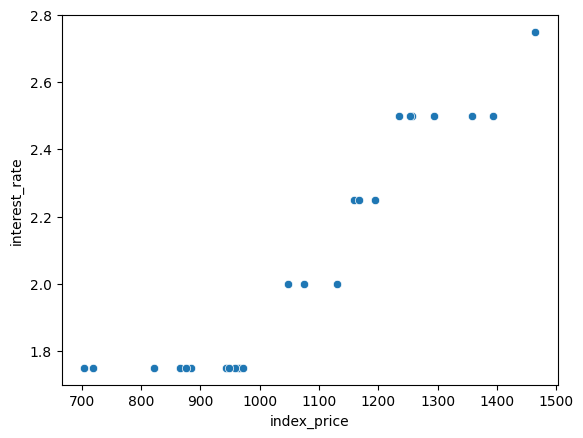

In [31]:
## interest rate and index price
sns.scatterplot(x='index_price',y = 'interest_rate',data=df)

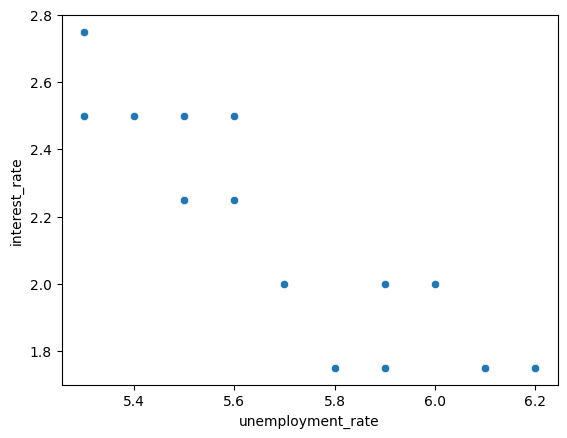

In [35]:
## Unimployment rate and index price
sns.scatterplot(x='unemployment_rate',y = 'interest_rate',data=df)
plt.show()

In [36]:
## Defining Depandant and Indepandant Features
X=df.iloc[:,:-1]
y = df.iloc[:,-1]

In [38]:
X.shape

(24, 2)

In [39]:
y.shape

(24,)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [42]:
X_train.shape

(19, 2)

In [43]:
y_train.shape

(19,)

In [45]:
X_test.shape,y_test.shape


((5, 2), (5,))

<Axes: xlabel='interest_rate', ylabel='index_price'>

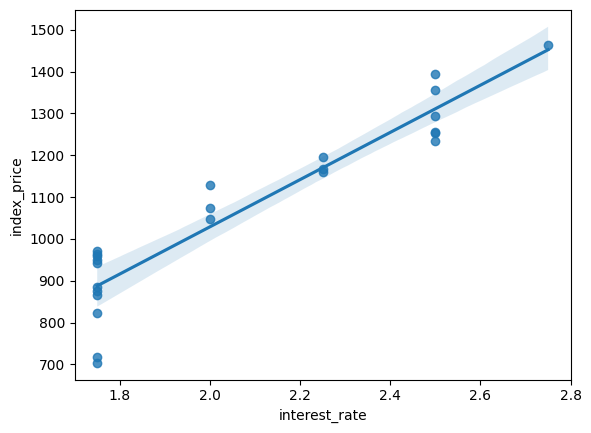

In [50]:
sns.regplot(x='interest_rate',y='index_price',data=df)

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

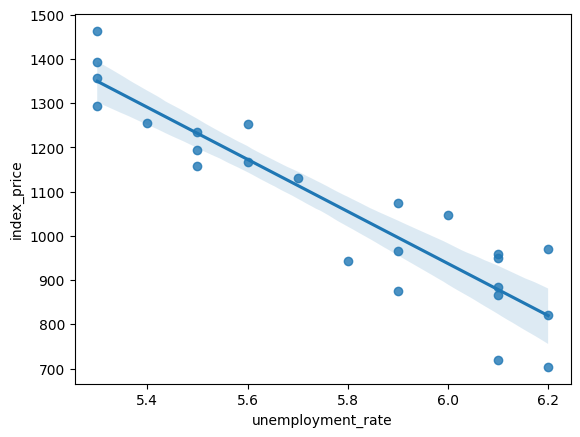

In [52]:
sns.regplot(x='unemployment_rate',y='index_price',data=df)

#### Scaling 

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
scaler.fit_transform(X_train)

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [56]:
X_train = scaler.fit_transform(X_train)

In [ ]:
scaler.mean_

array([2.06578947, 5.76842105])

In [59]:
X_test = scaler.transform(X_test)

In [60]:
X_test

array([[ 0.55339859, -0.84858687],
       [-0.9486833 ,  1.36439457],
       [ 2.05548048, -1.48086727],
       [-0.9486833 ,  1.04825436],
       [-0.19764235,  0.41597395]])

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
linear_model = LinearRegression(n_jobs=-1)

In [63]:
linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
print('The Slope or Coefficient of Best Fit line are: ',linear_model.coef_)
print('The Intercept of Best Fit Line is: ',linear_model.intercept_)

The Slope or Coefficient of Best Fit line are:  [  86.63351334 -114.04857249]
The Intercept of Best Fit Line is:  1059.4210526315792


#### `Prediction on Test Data`

In [68]:
y_pred = linear_model.predict(X_test)
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [67]:
y_test

8     1159
16     971
0     1464
18     884
11    1075
Name: index_price, dtype: int64

In [69]:
residuals = y_test - y_pred
residuals

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64

<Axes: xlabel='index_price', ylabel='Density'>

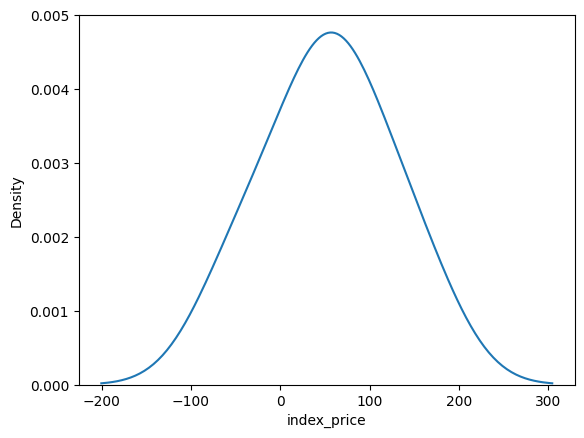

In [70]:
## kde plot of errors 
sns.kdeplot(residuals)

### Performance Metrics 

In [72]:
import numpy as np
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [73]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2_score = r2_score(y_test,y_pred)

print('Performance Metrics')
print('-'*40)
print('MSE: ',mse)
print('MAE: ',mae)
print('RMSE: ',rmse)
print('r2_score: ',r2_score)


Performance Metrics
----------------------------------------
MSE:  6957.105303258833
MAE:  71.71878409976625
RMSE:  83.40926389351985
r2_score:  0.8254940547158576


## Cross Validation Method (cross_val_score)

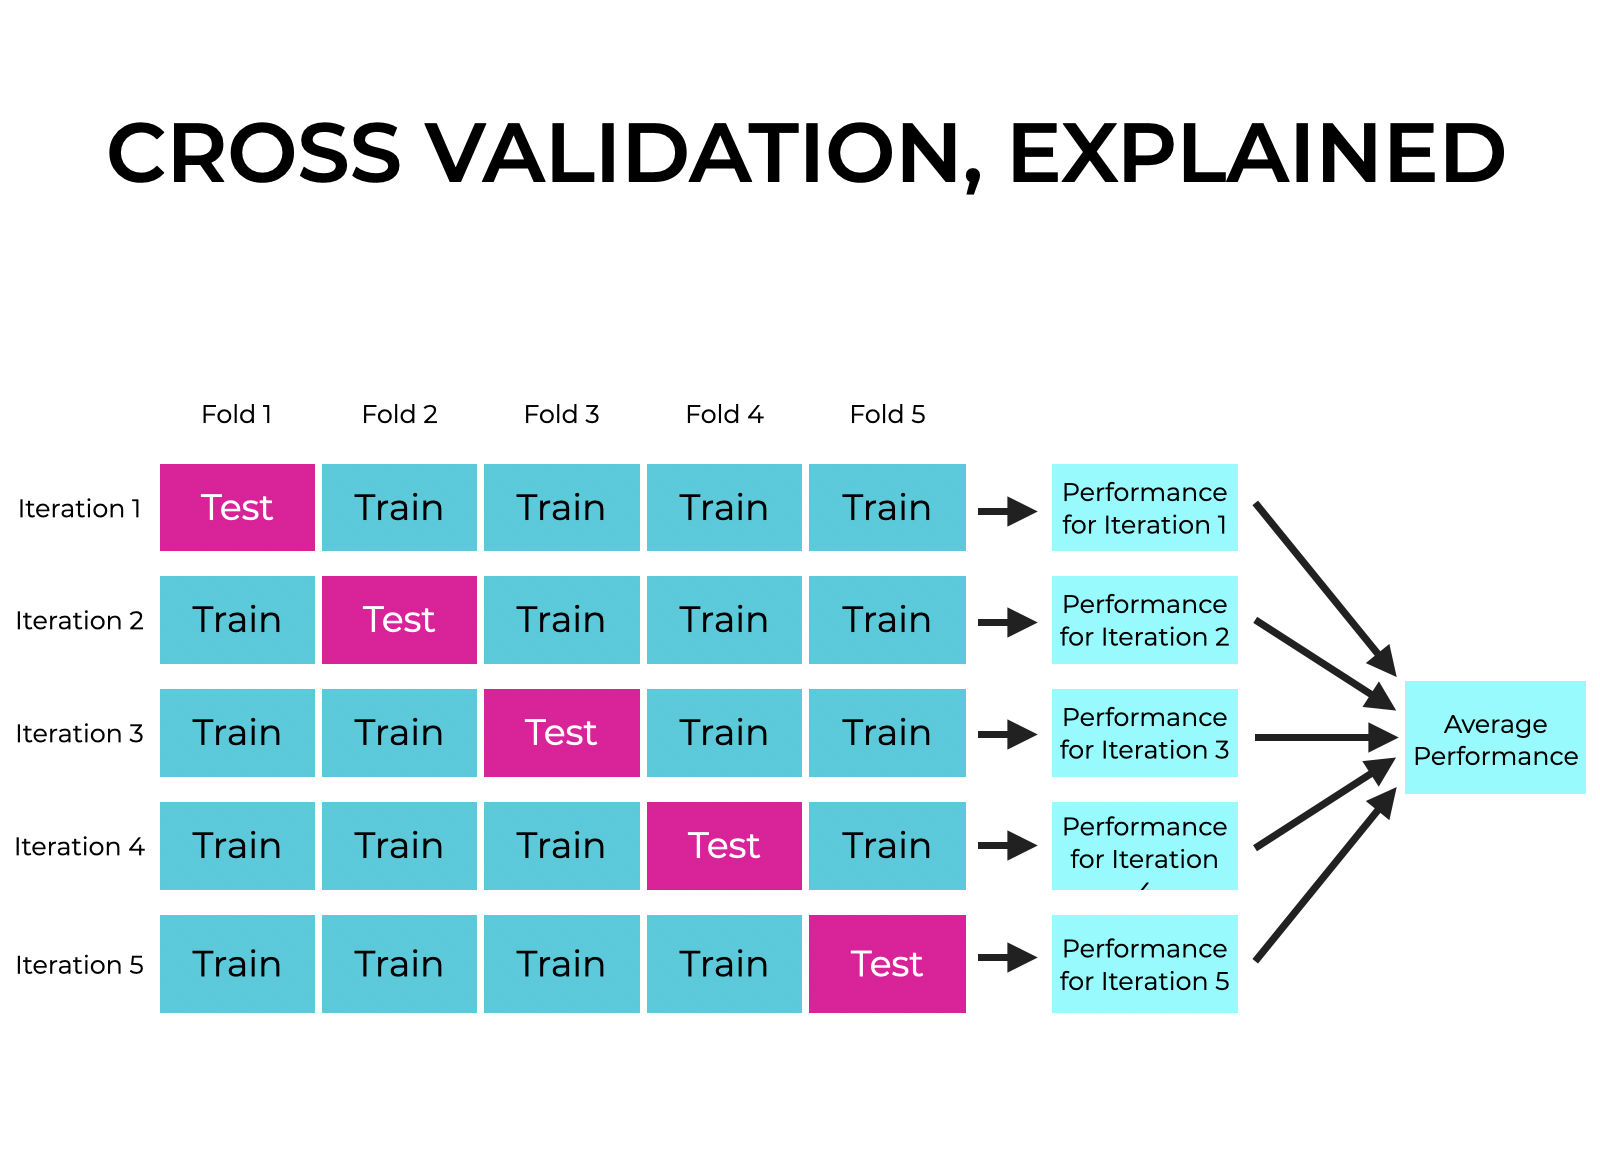

#### Syntax of Cross Val Score 

`cross_val_score(model_name,X_train,y_train,scoring = 'neg_mean_squared_error',cv=5)`  # you can also use other scoring parameter mse,mae etc


* The more -ive mse come close to 0 the more it is better
* In 5 fold cross validation we get 5 mse then we average them for final result.

In [74]:
from sklearn.model_selection import cross_val_score

In [ ]:
## Cross Validation

validation_score = cross_val_score(
                        linear_model,
                        X_train,
                        y_train,
                        scoring='neg_mean_squared_error',
                        cv=3
                        )

In [ ]:
# These are the three -ive mse values we take mean of them for final result 
validation_score

array([-4304.75412833, -7608.56499271, -5108.77588052])

In [80]:
print('Mean MSE: ',np.mean(validation_score))

Mean MSE:  -5674.031667186762


In [83]:
y_pred = linear_model.predict(X_test)

In [86]:
from sklearn.metrics import r2_score

In [87]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2_score = r2_score(y_test,y_pred)

print('Performance Metrics')
print('-'*40)
print('MSE: ',mse)
print('MAE: ',mae)
print('RMSE: ',rmse)
print('r2_score: ',r2_score)


Performance Metrics
----------------------------------------
MSE:  6957.105303258833
MAE:  71.71878409976625
RMSE:  83.40926389351985
r2_score:  0.8254940547158576


#### Adjusted R-Squared

In [88]:
print(1-(1-r2_score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.6509881094317151


### **Assumaptions**
* Based on this assumptions i will be able to conclude that whether my model will perform better or Not.

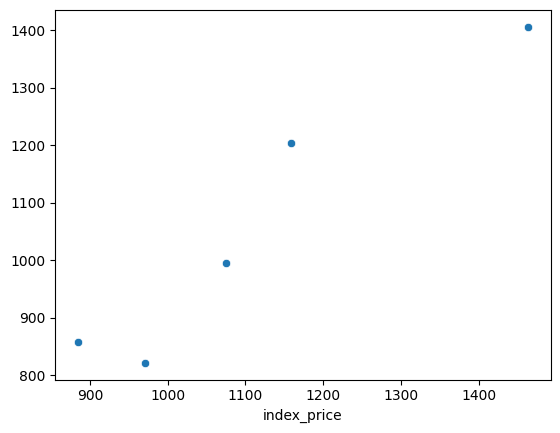

In [91]:
## 1- Plot a scatter plot b/w y_test and y_pred 
### If it show a linear relationship then your model is performing good
sns.scatterplot(x=y_test,y=y_pred)
plt.show()

* `Conclusion`
* The model prediction follow a linear relationship i can say the model is performing well

In [94]:
## 2- Find residuals by subtracting the prediction from the actual test data 
## then plot a kde plot 
residuals = y_test-y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


<Axes: xlabel='index_price', ylabel='Density'>

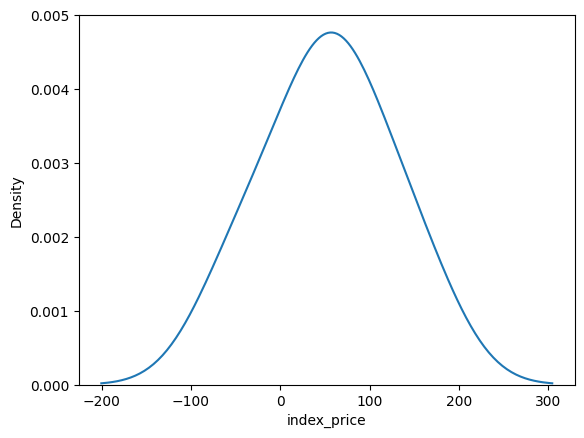

In [95]:
sns.kdeplot(residuals)

`Conclusion `
* If the kdeplot show a normal distribution the the model we created is good, so in our case it is normal 

<Axes: ylabel='index_price'>

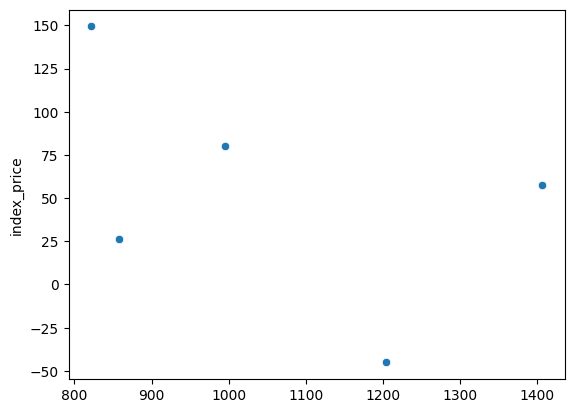

In [97]:
## 3- Create a Scatter plot b/w prediction and residuals 
sns.scatterplot(x=y_pred,y = residuals)

`Conclusion`
* here the data should follow a uniformly distributed , Our case we have very less data points , if we increase the datapoints then it follow a uniform distrubtion which show a good model 

## Multiple Linear Regression Using OLS

In [98]:
import statsmodels.api  as sm
model = sm.OLS(y_train,X_train).fit()

In [99]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Tue, 17 Feb 2026   Prob (F-statistic):                       0.751
Time:                        12:20:03   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [100]:
linear_model.coef_

array([  86.63351334, -114.04857249])

#### Multicollinearity

`Multicollinearity` is a statistical phenomenon in regression analysis where two or more independent variables (predictors) are highly linearly correlated, making it difficult to determine the individual effect of each predictor on the dependent variable